# Customer Review Sentiment Analysis

This project uses machine learning to classify customer reviews into positive or negative sentiment.

In [1]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB


In [2]:
import pandas as pd

In [3]:
data = {
    "review": [
        "The service was amazing",
        "Very bad experience",
        "Technician was late",
        "Excellent work and fast service",
        "Not satisfied with the service",
        "Very professional and polite",
        "Worst service ever",
        "I loved the quick response",
        "Terrible and slow",
        "Great and friendly technician",
        "Not good at all",
        "Very clean and professional work",
        "Horrible experience",
        "Super fast and reliable",
        "Very disappointing service",
        "Excellent technician",
        "Bad communication",
        "Quick and efficient service",
        "Not worth the money",
        "Highly recommended service"
    ],
    "sentiment": [
        "Positive","Negative","Negative","Positive","Negative","Positive",
        "Negative","Positive","Negative","Positive","Negative","Positive",
        "Negative","Positive","Negative","Positive","Negative","Positive",
        "Negative","Positive"
    ]
}

df = pd.DataFrame(data)

In [4]:
X = df["review"]
y = df["sentiment"]

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X_vectorized = vectorizer.fit_transform(X)

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_vectorized, y, test_size=0.2, random_state=42)

In [8]:
from sklearn.naive_bayes import MultinomialNB

In [9]:
model = MultinomialNB()
model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [10]:
test_review = ["The service was very good"]
test_vector = vectorizer.transform(test_review)

prediction = model.predict(test_vector)
print(prediction)

['Negative']


In [11]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.75


In [12]:
print(model.predict(vectorizer.transform(["The technician was rude"])))
print(model.predict(vectorizer.transform(["Amazing and fast service"])))

['Negative']
['Positive']


In [13]:
user_input = input("Enter a review: ")
prediction = model.predict(vectorizer.transform([user_input]))
print("Sentiment:", prediction[0])

Enter a review:  the service was bad


Sentiment: Negative


In [24]:
from sklearn.linear_model import LogisticRegression

model2 = LogisticRegression(max_iter=200)
model2.fit(X_train, y_train)

print("Logistic Regression Accuracy:", model2.score(X_test, y_test))

Logistic Regression Accuracy: 0.25


In [25]:
print("Naive Bayes Accuracy:", model.score(X_test, y_test))

Naive Bayes Accuracy: 0.75


In [26]:
test_review = ["The service was very good"]
prediction = model2.predict(vectorizer.transform(test_review))
print(prediction)

['Negative']


In [27]:
print("Best Model: Logistic Regression")

Best Model: Logistic Regression


In [28]:
!pip install matplotlib seaborn

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

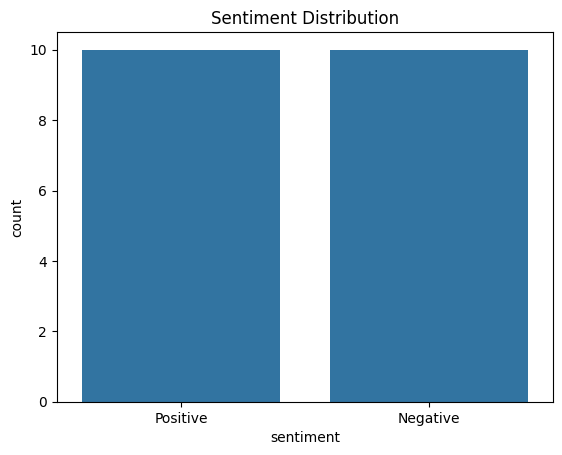

In [30]:
%matplotlib inline
sns.countplot(x=df['sentiment'])
plt.title("Sentiment Distribution")
plt.show()

In [31]:
print("Model Accuracy:", accuracy_score(y_test, y_pred))

Model Accuracy: 0.75


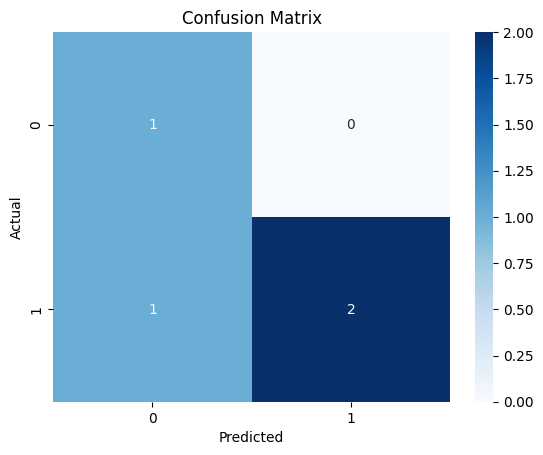

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()